# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Shivalika |
| **Role** | Person 5 — Time Series Patterns & LightGBM Model |
| **Notebook** | `Shivalika_Time_Series_Patterns.ipynb` |

---

## Sprint 1 — Exploratory Analysis (Merged Data)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
sys.path.append(os.path.abspath(".."))

In [ ]:
# ===============================
# 1. LOAD MERGED DATA
# ===============================
df = pd.read_csv("../data_processed/merged_train.csv")

In [ ]:
# Quick check
print(df.head())

In [ ]:
# ===============================
# 2. CONVERT TIMESTAMP
# ===============================
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# ===============================
# 3. FEATURE ENGINEERING
# ===============================
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["month"] = df["timestamp"].dt.month

### Hourly Energy Consumption

This plot shows how energy usage varies across different hours of the day for each meter type. 
It helps in identifying peak usage hours and understanding daily consumption patterns.

In [ ]:
# ===============================
# 4. AVERAGE ENERGY BY HOUR (per meter type)
# ===============================

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    hourly = subset.groupby("hour")["meter_reading"].mean()

    plt.figure(figsize=(10,4))
    sns.lineplot(x=hourly.index, y=hourly.values)

    # ✅ Set all 24 hours with AM/PM labels
    plt.xticks(
        ticks=range(24),
        labels=[
            "12 AM","1 AM","2 AM","3 AM","4 AM","5 AM",
            "6 AM","7 AM","8 AM","9 AM","10 AM","11 AM",
            "12 PM","1 PM","2 PM","3 PM","4 PM","5 PM",
            "6 PM","7 PM","8 PM","9 PM","10 PM","11 PM"
        ],
        rotation=45
    )

    plt.title(f"Meter {m} - Average Energy by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Meter Reading")

    plt.tight_layout()  # prevents overlap
    plt.show()

Observation:

Energy consumption is generally higher during daytime hours and lower during late night and early morning hours. 
This indicates that building activity significantly influences energy usage patterns.

### Monthly Energy Consumption

This plot illustrates how energy usage changes across different months of the year for each meter type. 
It helps in identifying seasonal trends in energy consumption.

In [ ]:
# ===============================
# 5. AVERAGE ENERGY BY MONTH (per meter type)
# ===============================

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for m in df["meter"].unique():
    subset = df[df["meter"] == m]
    monthly = subset.groupby("month")["meter_reading"].mean()

    plt.figure(figsize=(10,4))
    sns.lineplot(x=monthly.index, y=monthly.values)

    # ✅ Set month names
    plt.xticks(ticks=range(1,13), labels=month_labels, rotation=45)

    plt.title(f"Meter {m} - Average Energy by Month")
    plt.xlabel("Month")
    plt.ylabel("Meter Reading")

    plt.tight_layout()
    plt.show()

Observation:

Energy usage varies across months, indicating seasonal trends. 
Higher consumption in certain months may be due to increased heating or cooling demands depending on weather conditions.

### Weekday vs Weekend Energy Usage

This plot compares the average energy consumption between weekdays and weekends. 
It helps in understanding how operational patterns affect energy usage.

In [ ]:
# ===============================
# 6. WEEKDAY vs WEEKEND
# ===============================

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    week = subset.groupby("is_weekend")["meter_reading"].mean().reset_index()

    plt.figure(figsize=(6,4))
    sns.barplot(
        data=week,
        x="is_weekend",
        y="meter_reading",
        hue="is_weekend",      
        palette="coolwarm",
        legend=False           
    )

    plt.xticks([0,1], ["Weekday", "Weekend"])

    plt.title(f"Meter {m} - Weekend vs Weekday")
    plt.xlabel("")
    plt.ylabel("Meter Reading")

    plt.tight_layout()
    plt.show()

Observation:

Energy consumption is generally higher on weekdays compared to weekends. 
This suggests that buildings are more actively used during working days, leading to increased energy demand.

### Energy Consumption Timeline for Selected Buildings

This plot shows the energy usage trend over time for three selected buildings across the year 2016. 
It helps in understanding how energy consumption varies over time at the building level.

In [ ]:
# ===============================
# 7. 3 BUILDINGS TIMELINE (2016)
# ===============================
import matplotlib.dates as mdates

for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    if len(subset) == 0:
        continue

    # pick 3 buildings
    sample_buildings = subset["building_id"].drop_duplicates().sample(3, random_state=42)
    subset_3 = subset[subset["building_id"].isin(sample_buildings)]

    # convert timestamp to weekly average
    subset_3 = subset_3.set_index("timestamp")
    # filter only 2016
    subset_3 = subset_3[
    (subset_3.index >= "2016-01-01") & 
    (subset_3.index < "2017-01-01")
]
    weekly = subset_3.groupby(["building_id"]).resample("W")["meter_reading"].mean().reset_index()

    plt.figure(figsize=(12,6))
    sns.lineplot(data=weekly, x="timestamp", y="meter_reading", hue="building_id")

    # FORMAT X-AXIS TO MONTH NAMES
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # every month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, Mar

    plt.title(f"Meter {m} - Weekly Energy Trend (3 Buildings)")
    plt.xlabel("2016 Timeline")
    plt.ylabel("Meter Reading")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Observation:

The energy usage shows fluctuations over time, with some consistent patterns visible across buildings. 
Due to high-frequency variations in the data, the overall trend is more important than individual spikes. 
This indicates that energy consumption follows recurring patterns with some variability across buildings.

### Heatmap of Energy Usage (Month vs Hour)

This heatmap represents the average energy consumption across different months and hours of the day. 
It provides a combined view of both daily and seasonal patterns in energy usage.

In [ ]:
# ===============================
# 8. HEATMAP (Month vs Hour)
# ===============================
for m in df["meter"].unique():
    subset = df[df["meter"] == m]

    heatmap_data = subset.pivot_table(
        values="meter_reading",
        index="month",
        columns="hour",
        aggfunc="mean"
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(heatmap_data, cmap="coolwarm")
    plt.title(f"Meter {m} - Heatmap (Month vs Hour)")
    plt.show()

Observation:

The heatmap shows that energy usage depends on both time of day and month. 
Certain hours and months exhibit higher consumption, indicating peak usage periods. 
This combined effect highlights the importance of temporal features in understanding energy patterns.

In [ ]:
# ===============================
# 9. SUMMARY STATISTICS (OPTIONAL BUT GOOD)
# ===============================
print("\nSummary Statistics:")
print(df["meter_reading"].describe())

Key Findings:

• Time-based features (hour, day_of_week, month) were successfully extracted from the timestamp for temporal analysis

• Hourly analysis shows that peak energy usage occurs during afternoon hours (approximately 12 PM – 4 PM), while lowest usage is observed during early morning hours (12 AM – 5 AM)

• Monthly trends show clear seasonal variation:
  o Meter 0 peaks around July–September (~180–190) and is lowest in January–March (~145–155)
  o Meter 1 shows highest usage around September (~1700–1800) and lowest in January (~150–200)
  o Meter 2 has extremely high values in March–May (~38,000–40,000) and drops significantly after June
  o Meter 3 shows higher usage at the beginning and end of the year (~600–650) and lowest around mid-year (~150–250)

• Weekday vs weekend comparison shows consistently higher energy usage on weekdays across all meters:
  o Meter 0: ~175 (weekday) vs ~155 (weekend)
  o Meter 1: ~650 vs ~600
  o Meter 2: ~14,500 vs ~12,000
  o Meter 3: ~390 vs ~380

• Weekly trend analysis (smoothed timeline) shows consistent seasonal patterns across buildings, with gradual increases and decreases rather than random noise

• Heatmap analysis (month vs hour) highlights that peak energy usage occurs during afternoon hours (12–4 PM) and specific months depending on meter type

• Significant variation exists between meter types, with Meter 2 having much higher values compared to others, so separate visualizations were used for clarity

• Overall, energy consumption is strongly influenced by temporal features such as hour, day, and month, making them important for further modelling

---

## Sprint 2 — Time Series Patterns & Feature Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
train_path = r"../data_processed/final_train.csv"
val_path = r"../data_processed/final_val.csv"
test_path = r"../data_processed/final_test.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

In [ ]:
print(train_df.head())
print(test_df.head())

In [ ]:
print("\n--- DATASET OVERVIEW ---")
print("Shape:", train_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nData Types:")
print(train_df.dtypes)

The dataset contains building-level energy readings along with temporal and environmental features.

In [ ]:
print("\n--- TARGET DESCRIPTION ---")
print(train_df['meter_reading'].describe())

plt.figure()
plt.hist(train_df['meter_reading'], bins=50)
plt.title("Distribution of Meter Reading")
plt.xlabel("Meter Reading")
plt.ylabel("Frequency")
plt.show()

Analyze distribution of energy consumption.

Data PreProcessing

In [ ]:
# Convert timestamp to datetime
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
val_df['timestamp'] = pd.to_datetime(val_df['timestamp'])

# Sort data for time-series correctness
train_df = train_df.sort_values(['building_id', 'meter', 'timestamp'])
test_df = test_df.sort_values(['building_id', 'meter', 'timestamp'])
val_df = val_df.sort_values(['building_id', 'meter', 'timestamp'])

print("\n--- TIMESTAMP CHECK ---")
print(train_df[['timestamp']].head())
print(test_df[['timestamp']].head())
print(val_df[['timestamp']].head())

Timestamps are converted into datetime format and data is sorted chronologically to ensure correct time-series processing.

Lag Features

Lag features (24h, 72h, 168h) are created to capture past consumption patterns.

Rolling features capture trends and variability over time.

A shift operation is applied before rolling to avoid data leakage.

The dataset is sorted to maintain temporal order.

In [ ]:
def add_lag_features(df):
    df = df.sort_values(['building_id', 'meter', 'timestamp']).copy()
    df['lag_24h'] = df.groupby(['building_id','meter'])['meter_reading'].shift(24)
    df['lag_72h'] = df.groupby(['building_id','meter'])['meter_reading'].shift(72)
    df['lag_168h'] = df.groupby(['building_id','meter'])['meter_reading'].shift(168)
    return df

train_df = add_lag_features(train_df)
val_df = add_lag_features(val_df)


print(train_df[['meter_reading','lag_24h','lag_72h','lag_168h']].head(10))
print(val_df[['meter_reading','lag_24h','lag_72h','lag_168h']].head(10))



Lag features capture past values of energy consumption:

24h → previous day
72h → 3 days
168h → 1 week

These help the model learn temporal dependencies.

Rolling Features (Avoiding Data Leakage)

In [ ]:
def add_rolling_features(df):
    df = df.sort_values(['building_id', 'meter', 'timestamp']).copy()
    grouped = df.groupby(['building_id','meter'])['meter_reading']
    df['rolling_mean_24h'] = grouped.transform(lambda x: x.shift(1).rolling(24).mean())
    df['rolling_std_24h'] = grouped.transform(lambda x: x.shift(1).rolling(24).std())
    df['rolling_mean_168h'] = grouped.transform(lambda x: x.shift(1).rolling(168).mean())
    return df

train_df = add_rolling_features(train_df)
val_df = add_rolling_features(val_df)

print("\n--- ROLLING FEATURES SAMPLE ---")
print(train_df[['rolling_mean_24h','rolling_std_24h']].head(10))
print(val_df[['rolling_mean_24h','rolling_std_24h']].head(10))

Rolling features capture trends and variability over time.
A shift is applied before rolling to prevent data leakage (future data influencing predictions).

In [ ]:
sample1 = train_df[train_df['building_id'] == 105]
sample2 = val_df[val_df['building_id'] == 105]


print(sample1[['meter_reading','rolling_mean_24h']].head(30))
print(sample2[['meter_reading','rolling_mean_24h']].head(30))

Handle Missing Values

In [ ]:
feature_cols = [
    'lag_24h','lag_72h','lag_168h',
    'rolling_mean_24h','rolling_std_24h','rolling_mean_168h'
]

required_history_cols = [
    'lag_24h','lag_168h','rolling_mean_24h','rolling_std_24h'
]

train_df = train_df.dropna(subset=required_history_cols)
val_df = val_df.dropna(subset=required_history_cols)

print("\n--- MISSING VALUES AFTER HANDLING ---")
print("Train:")
print(train_df[feature_cols].isnull().sum())
print("\nValidation:")
print(val_df[feature_cols].isnull().sum())

Missing values occur due to shifting and rolling operations.
These are handled using zero imputation to maintain dataset consistency.

In [ ]:
print("\n--- FEATURE CHECK (NON-ZERO VALUES) FOR TRAIN DATA ---")
print(train_df[['meter_reading','lag_24h','rolling_mean_24h']].iloc[200:210])


print("\n--- FEATURE CHECK (NON-ZERO VALUES) FOR VALIDATION DATA ---")
print(val_df[['meter_reading','lag_24h','rolling_mean_24h']].iloc[200:210])

Verify features are correctly computed.

Validation Checks

In [ ]:
print("\n--- CHECK SORTING FOR TRAIN DATA ---")
print(train_df[['building_id','meter','timestamp']].head())

print("\n--- MISSING VALUES FOR TRAIN DATA ---")
print(train_df[feature_cols].isnull().sum())


print("\n--- CHECK SORTING FOR VALIDATION DATA ---")
print(val_df[['building_id','meter','timestamp']].head())

print("\n--- MISSING VALUES FOR VALIDATION DATA ---")
print(val_df[feature_cols].isnull().sum())


Validation ensures:

Data is properly sorted
No missing values remain in engineered features

CORRELATION ANALYSIS

In [ ]:
corr1 = train_df[['meter_reading','lag_24h','lag_168h','rolling_mean_24h']].corr()
corr2 = val_df[['meter_reading','lag_24h','lag_168h','rolling_mean_24h']].corr()

print("\n--- CORRELATION MATRIX FOR TRAIN DATA ---")
print(corr1)
print("\n--- CORRELATION MATRIX FOR VALIDATION DATA ---")
print(corr2)

Check relationship between engineered features and target.

Lag Feature Visualization

In [ ]:
sample1 = train_df[train_df['building_id'] == 105].head(200)
sample2 = val_df[val_df['building_id'] == 105].head(200)

plt.figure()
plt.plot(sample1['timestamp'], sample1['meter_reading'], label='Original')
plt.plot(sample1['timestamp'], sample1['lag_24h'], label='Lag 24h')
plt.legend()
plt.title("Lag Feature Visualization")
plt.xticks(rotation=45)
plt.show()

plt.plot(sample2['timestamp'], sample2['meter_reading'], label='Original')
plt.plot(sample2['timestamp'], sample2['lag_24h'], label='Lag 24h')
plt.legend()
plt.title("Lag Feature Visualization (Validation)")
plt.xticks(rotation=45)
plt.show()




Visualization helps verify feature behavior.
The lag feature clearly represents past values of the original time series.

Rolling Mean Trend

In [ ]:
plt.figure()
plt.plot(sample1['timestamp'], sample1['meter_reading'], label='Original')
plt.plot(sample1['timestamp'], sample1['rolling_mean_24h'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Trend")
plt.xticks(rotation=45)
plt.show()


plt.plot(sample2['timestamp'], sample2['meter_reading'], label='Original')
plt.plot(sample2['timestamp'], sample2['rolling_mean_24h'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Trend (Validation)")    
plt.xticks(rotation=45)
plt.show()


In [ ]:
# ==============================
# SAVE DATA
# ==============================

import os

output_path = "../data_processed"

# create folder if not exists
os.makedirs(output_path, exist_ok=True)

train_df.to_csv(output_path + "/final_train_with_features.csv", index=False)
val_df.to_csv(output_path + "/final_val_with_features.csv", index=False)

# Test has no meter_reading, so lag/rolling target-history features cannot be created here
# without recursive model predictions. Test-time lag features are deferred to the model notebook.
test_df.to_csv(output_path + "/final_test.csv", index=False)

print("Files saved. ")

INSIGHTS:

1. Energy consumption exhibits strong temporal patterns, as seen from the effectiveness of lag features.

2. Lag features such as 24-hour and 168-hour lags show that energy usage follows daily and weekly cycles.

3. Rolling statistics (mean and standard deviation) help capture trends and smooth short-term fluctuations in energy consumption.

4. The use of shift before rolling ensures that only past data is used, preventing data leakage and making the features reliable for prediction.

5. Initial missing values are generated due to insufficient historical data for lag and rolling calculations, and these were handled appropriately.

6. Correlation analysis indicates that lag features are strongly related to the target variable, confirming their usefulness for modeling.

7. Overall, feature engineering significantly improves the dataset by incorporating time-based dependencies, making it more suitable for accurate energy consumption forecasting.

---

## Sprint 3 — LightGBM Model Development & Tuning

In [2]:
import pandas as pd
train_df = pd.read_csv("../data_processed/final_train_with_features.csv")
val_df   = pd.read_csv("../data_processed/final_val_with_features.csv")
test_df  = pd.read_csv("../data_processed/final_test.csv")

Define Final Feature List - FEATURE SELECTION

In [3]:
drop_cols = ["timestamp", "row_id"] if "row_id" in train_df.columns else ["timestamp"]

feature_cols = [
    col for col in train_df.columns
    if col not in drop_cols + ["meter_reading", "log_meter_reading"]
]

X_train = train_df[feature_cols]
y_train = train_df["meter_reading"]

X_val = val_df[feature_cols]
y_val = val_df["meter_reading"]

print("Leakage check:", "log_meter_reading" in X_train.columns)

Leakage check: False


Log Transform Target

In [4]:
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [5]:
drop_cols_test = ["timestamp", "row_id"] if "row_id" in test_df.columns else ["timestamp"]
X_test = test_df.drop(columns=drop_cols_test, errors='ignore')

#  Check mismatch BEFORE fixing
print("Missing in test:", set(X_train.columns) - set(X_test.columns))
print("Extra in test:", set(X_test.columns) - set(X_train.columns))

# Add missing columns as NaN
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = np.nan

#  Ensure same order
X_test = X_test[X_train.columns]

Missing in test: {'lag_168h', 'lag_72h', 'rolling_mean_24h', 'rolling_mean_168h', 'lag_24h', 'rolling_std_24h'}
Extra in test: set()


Train LightGBM Model

In [6]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_log)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.895125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3907
[LightGBM] [Info] Number of data points in the train set: 14183013, number of used features: 46
[LightGBM] [Info] Start training from score 4.363338


LGBMRegressor(learning_rate=0.05, n_estimators=500, n_jobs=-1, random_state=42)

We train a LightGBM regression model using the processed training data to learn patterns in energy consumption.

Predict on Validation Set

In [7]:
y_pred_log = model.predict(X_val)
y_pred = np.expm1(y_pred_log)

Compute RMSLE

In [8]:
import sys
import os
sys.path.append(os.path.abspath(".."))


from shared.metrics import rmsle

rmsle_1 = rmsle(y_val, y_pred)
print("RMSLE Model 1:", rmsle_1)

RMSLE Model 1: 0.5162482971587313


In [9]:
meter_names = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}

val_df["predicted"] = y_pred

print("RMSLE per Meter Type:")
for meter, group in val_df.groupby("meter"):
    m_rmsle = rmsle(group["meter_reading"], group["predicted"])
    print(f"  Meter {meter} ({meter_names.get(meter, meter)}): {m_rmsle:.4f}")
print(f"  Overall: {rmsle_1:.4f}")

RMSLE per Meter Type:
  Meter 0 (Electricity): 0.2583
  Meter 1 (Chilled Water): 0.6819
  Meter 2 (Steam): 0.7234
  Meter 3 (Hot Water): 1.0862
  Overall: 0.5162


We compute RMSLE to evaluate model performance, which is suitable for skewed data like energy usage.

Second Model (Hyperparameter Tuning)

In [10]:
model2 = lgb.LGBMRegressor(
    n_estimators=150,        
    learning_rate=0.1,       
    num_leaves=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1                
)

model2.fit(X_train, y_train_log)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.807161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3907
[LightGBM] [Info] Number of data points in the train set: 14183013, number of used features: 46
[LightGBM] [Info] Start training from score 4.363338


LGBMRegressor(max_depth=10, n_estimators=150, n_jobs=-1, num_leaves=50,
              random_state=42)

In [11]:
y_pred_log_2 = model2.predict(X_val)
y_pred_2 = np.expm1(y_pred_log_2)

rmsle_2 = rmsle(y_val, y_pred_2)
print("RMSLE Model 2:", rmsle_2)

RMSLE Model 2: 0.5181882805464838


FINAL COMPARISON


In [12]:
print("\nFinal Comparison:")
print("Model 1 RMSLE:", rmsle_1)
print("Model 2 RMSLE:", rmsle_2)


Final Comparison:
Model 1 RMSLE: 0.5162482971587313
Model 2 RMSLE: 0.5181882805464838


Selecting best model

In [13]:
best_model = model if rmsle_1 < rmsle_2 else model2



Test Prediction

In [14]:
test_preds_log = best_model.predict(X_test)
test_preds = np.expm1(test_preds_log)
print("Test predictions generated:", len(test_preds))


Test predictions generated: 41697600


Saving Submission

In [15]:
os.makedirs("../outputs", exist_ok=True)

submission = test_df[["row_id"]].copy()
submission["meter_reading"] = test_preds

submission.to_csv("../outputs/test_predictions.csv", index=False)

print("Test predictions saved")

Test predictions saved


Saving Model

In [16]:
import pickle

with open("../outputs/lightgbm_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully")

Model saved successfully


Feature Importance

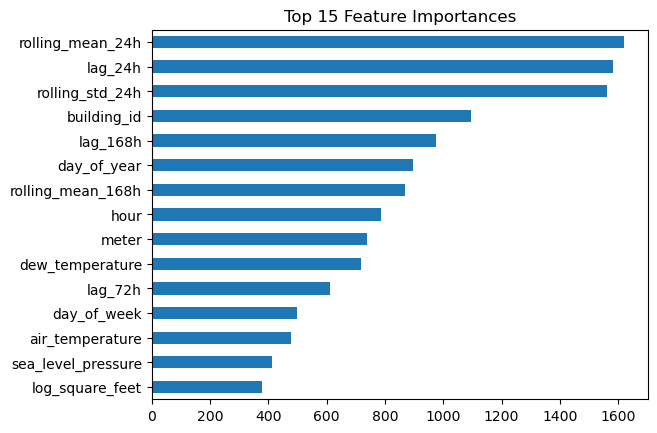

In [17]:
import matplotlib.pyplot as plt

importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False).head(15)

importance[::-1].plot(kind="barh")
plt.title("Top 15 Feature Importances")
plt.show()

**INSIGHTS:**

1. The baseline LightGBM model achieved an RMSLE of approximately 0.516, providing a reliable benchmark for model performance on the shared validation set.

2. The second model, with modified hyperparameters, achieved a slightly higher RMSLE (~0.518), indicating that it did not outperform the baseline and suggesting limited benefit from increased model complexity.

3. The comparison highlights that hyperparameter tuning does not always guarantee improved performance, and simpler configurations can generalize better.

4. The evaluation using a consistent validation dataset ensured fair comparison across models, making the results directly comparable within the team.

5. The use of RMSLE as the evaluation metric proved effective for handling skewed energy consumption data, allowing better assessment of prediction accuracy.

6. Overall, the baseline LightGBM model was selected as the best-performing model based on validation performance and was used for final test predictions.



---

## Sprint 4 — Evaluation & Report